# 8.1 Decision Trees for Classification

**COMP SCI 465: Machine Learning** | Section 8.1

## Learning objectives
- Define and use a decision tree
- Describe how a classification tree is trained
- Implement a classification tree in scikit-learn
- Define impurity measures (Gini, entropy)
- Implement early stopping in DecisionTreeClassifier
- Describe cost complexity pruning
- Understand advantages and disadvantages of classification trees

## 1. Imports and setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
from sklearn.tree import plot_tree

## 2. Try 8.1.1: Decision tree classifiers with the coffee dataset

The Coffee Quality Institute dataset contains taste-test results (sweetness, uniformity, aroma, aftertaste, etc.) and species (Arabica vs Robusta).

In [2]:
# Load coffee data from Coffee Quality Institute (jldbc/coffee-quality-database)
arabica_url = "https://raw.githubusercontent.com/jldbc/coffee-quality-database/master/data/arabica_data_cleaned.csv"
robusta_url = "https://raw.githubusercontent.com/jldbc/coffee-quality-database/master/data/robusta_data_cleaned.csv"

df_arabica = pd.read_csv(arabica_url)
df_robusta = pd.read_csv(robusta_url)

# Align column names: Arabica uses Sweetness, Uniformity; Robusta uses different names
# Arabica: Aroma, Flavor, Aftertaste, Acidity, Body, Balance, Uniformity, Clean.Cup, Sweetness
# Robusta: Fragrance...Aroma -> Aroma, Uniform.Cup -> Uniformity, Bitter...Sweet -> Sweetness
arabica_cols = ['Sweetness', 'Uniformity', 'Aroma', 'Aftertaste', 'Flavor']
robusta_col_map = {'Fragrance...Aroma': 'Aroma', 'Uniform.Cup': 'Uniformity', 'Bitter...Sweet': 'Sweetness'}

df_arabica_sub = df_arabica[['Species'] + arabica_cols].copy()
df_robusta_sub = df_robusta.rename(columns=robusta_col_map)[['Species'] + arabica_cols].copy()

# Combine and drop rows with missing values
coffee = pd.concat([df_arabica_sub, df_robusta_sub], ignore_index=True)
coffee = coffee.dropna()

print(f"Coffee dataset shape: {coffee.shape}")
print(coffee['Species'].value_counts())

Coffee dataset shape: (1339, 6)
Species
Arabica    1311
Robusta      28
Name: count, dtype: int64


In [3]:
# Features and target (Try 8.1.1: change sweetness/uniformity to aroma/aftertaste to explore)
feature_cols = ['sweetness', 'uniformity']  # lowercase to match our renamed cols
coffee_lower = coffee.copy()
coffee_lower.columns = [c.lower().replace('.', '_').replace(' ', '_') for c in coffee.columns]
feature_cols = ['sweetness', 'uniformity']

X = coffee_lower[feature_cols]
y = coffee_lower['species']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize and fit decision tree classifier
DTC = DecisionTreeClassifier()
DTC.fit(X_train, y_train)

# Predictions
y_pred = DTC.predict(X_test)
y_test_p = DTC.predict_proba(X_test)  # proportion in final leaf for each instance

print("Class labels:", DTC.classes_)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion matrix:")
print(confusion_matrix(y_test, y_pred))

Class labels: ['Arabica' 'Robusta']
Accuracy: 0.996268656716418

Confusion matrix:
[[258   1]
 [  0   9]]


/opt/homebrew/Caskroom/miniforge/base/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


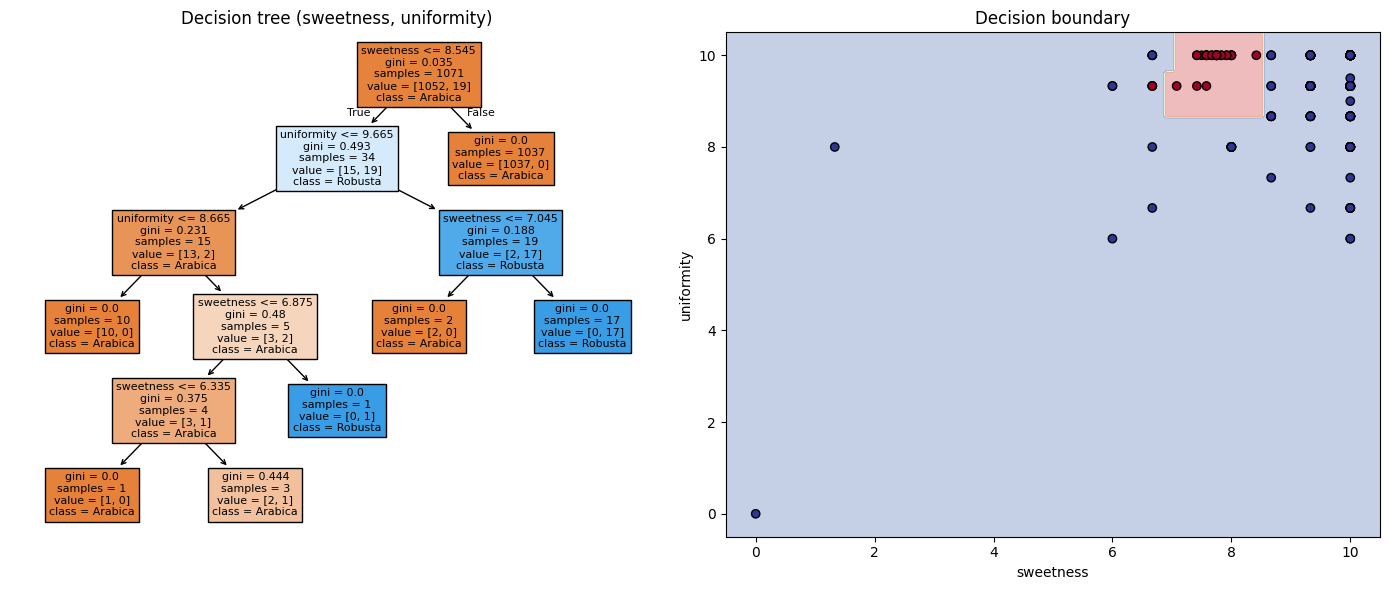

In [4]:
# Visualize the tree and decision boundary
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

plot_tree(DTC, feature_names=feature_cols, class_names=list(DTC.classes_), filled=True, ax=axes[0])
axes[0].set_title("Decision tree (sweetness, uniformity)")

# Decision boundary (mesh)
x_min, x_max = X[feature_cols[0]].min() - 0.5, X[feature_cols[0]].max() + 0.5
y_min, y_max = X[feature_cols[1]].min() - 0.5, X[feature_cols[1]].max() + 0.5
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200), np.linspace(y_min, y_max, 200))
Z = DTC.predict(np.c_[xx.ravel(), yy.ravel()])
Z = (Z == 'Arabica').astype(int)
Z = Z.reshape(xx.shape)
axes[1].contourf(xx, yy, Z, alpha=0.3, cmap='RdYlBu')
scatter = axes[1].scatter(X[feature_cols[0]], X[feature_cols[1]], c=(y == 'Arabica').astype(int), cmap='RdYlBu', edgecolors='k')
axes[1].set_xlabel(feature_cols[0])
axes[1].set_ylabel(feature_cols[1])
axes[1].set_title("Decision boundary")
plt.tight_layout()
plt.show()

## 3. Try 8.1.2: Early stopping parameters

| Parameter | Default | Description |
|-----------|---------|-------------|
| `max_depth` | None | Max depth of leaves |
| `min_samples_split` | 2 | Min instances to search for a split |
| `min_samples_leaf` | 1 | Min instances in each leaf |
| `max_leaf_nodes` | None | Max number of leaves |

Accuracy (small tree): 0.9850746268656716

Confusion matrix:
[[257   2]
 [  2   7]]


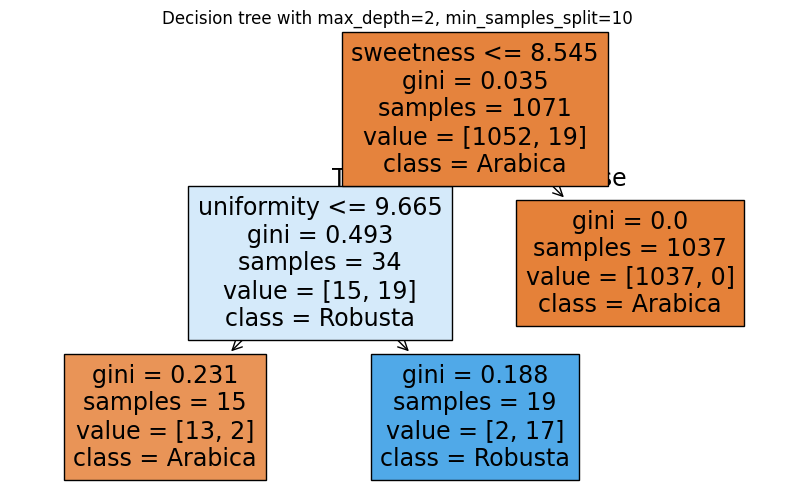

In [5]:
# Smaller tree with early stopping
DTC_small = DecisionTreeClassifier(max_depth=2, min_samples_split=10, criterion='gini')
DTC_small.fit(X_train, y_train)

y_pred_small = DTC_small.predict(X_test)
print("Accuracy (small tree):", accuracy_score(y_test, y_pred_small))
print("\nConfusion matrix:")
print(confusion_matrix(y_test, y_pred_small))

plt.figure(figsize=(10, 6))
plot_tree(DTC_small, feature_names=feature_cols, class_names=list(DTC_small.classes_), filled=True)
plt.title("Decision tree with max_depth=2, min_samples_split=10")
plt.show()

## 4. Impurity measures: Gini vs Entropy

- **Gini impurity**: $1 - \sum_k p_k^2$ (default, `criterion='gini'`)
- **Entropy**: $-\sum_k p_k \log(p_k)$ (`criterion='entropy'`)

In [6]:
DTC_gini = DecisionTreeClassifier(criterion='gini', max_depth=3)
DTC_entropy = DecisionTreeClassifier(criterion='entropy', max_depth=3)

DTC_gini.fit(X_train, y_train)
DTC_entropy.fit(X_train, y_train)

print("Gini - Test accuracy:", accuracy_score(y_test, DTC_gini.predict(X_test)))
print("Entropy - Test accuracy:", accuracy_score(y_test, DTC_entropy.predict(X_test)))

Gini - Test accuracy: 0.9888059701492538
Entropy - Test accuracy: 0.996268656716418


## 5. Cost complexity pruning (`ccp_alpha`)

Pruning balances tree impurity vs number of leaves. Set `ccp_alpha > 0` to enable.

Pruned tree - Test accuracy: 0.9813432835820896


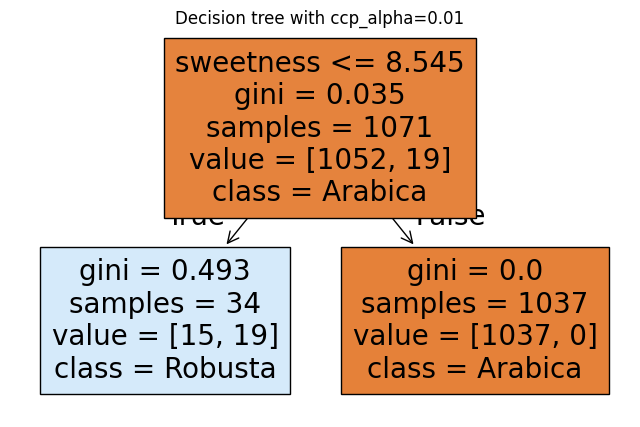

In [7]:
DTC_pruned = DecisionTreeClassifier(ccp_alpha=0.01)
DTC_pruned.fit(X_train, y_train)

print("Pruned tree - Test accuracy:", accuracy_score(y_test, DTC_pruned.predict(X_test)))
plt.figure(figsize=(8, 5))
plot_tree(DTC_pruned, feature_names=feature_cols, class_names=list(DTC_pruned.classes_), filled=True)
plt.title("Decision tree with ccp_alpha=0.01")
plt.show()

## 6. Challenge 8.1.2: Heart disease dataset

Initialize a decision tree classifier using **Gini impurity** as the impurity measure.

In [8]:
# Load heart dataset
heart_path = "heart.csv"  # in same folder as notebook
heart = pd.read_csv(heart_path)

X_heart = heart[['age', 'trestbps', 'chol', 'thalach']]
y_heart = heart['target']

X_h_train, X_h_test, y_h_train, y_h_test = train_test_split(X_heart, y_heart, test_size=0.2, random_state=42)

# Initialize DTCHeart with Gini impurity
DTCHeart = DecisionTreeClassifier(criterion='gini')
DTCHeart.fit(X_h_train, y_h_train)

print("DTCHeart parameters:", DTCHeart.get_params())
print("Test accuracy:", accuracy_score(y_h_test, DTCHeart.predict(X_h_test)))

DTCHeart parameters: {'ccp_alpha': 0.0, 'class_weight': None, 'criterion': 'gini', 'max_depth': None, 'max_features': None, 'max_leaf_nodes': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'random_state': None, 'splitter': 'best'}
Test accuracy: 0.9


---
## Participation activity answers (8.1)

### 8.1.2: Decision trees (coffee species)
- **C. arabica** is a **leaf** (no outgoing edges).
- **Asymmetric beans + needs pollinator** → follow left at root (asymmetric) → leaf **C. liberica**.
- **Depth 1 leaf**: **C. liberica** (one edge from root: asymmetric).

### 8.1.4: Making predictions from a decision tree
- **Coffee from India, clean cup 10**: Root sends India → left → leaf **Robusta** (country alone decides).
- **All Indian coffees in sample**: Go to same leaf (Robusta, 0 Arabica) → **pure** leaf.
- **Why country first?** It best separates Robusta from Arabica (highest information gain).

### 8.1.5: Basic decision tree classifiers in scikit-learn
1. `DTC = DecisionTreeClassifier()`
2. `y_test_p = DTC.predict_proba(X_test)`
3. `DTC.classes_`

### 8.1.6: Impurity measures
- Gini and entropy both reach **maximum** when class proportions are equal.
- Lower impurity = better split; the split with lowest Gini (or entropy) is preferred.

### 8.1.7: Early stopping conditions
1. **max_depth=4** — guarantees max leaf depth of 4
2. **min_samples_leaf=4** — guarantees at least 4 instances per leaf
3. **min_samples_split=0.1** (float) — 10% of training instances at node

### 8.1.8–8.1.9: Cost complexity pruning
- If $C_{leaf} \leq C_{subtree}$, **prune** (replace subtree with leaf).
- $C(T) = R(T) + \alpha |T|$; larger $\alpha$ → more pruning.

### 8.1.10: Advantages and disadvantages
1. **Correlated features / stair-step boundaries** — penguins: bill length and body mass are correlated; trees split on one feature at a time, causing stair-step patterns.
2. **Sweetness is the top split** — it best separates Arabica (sweetness > 8.545) from Robusta; the leaf with 1291 Arabica and 0 Robusta is pure.

### Challenge 8.1.1: MPG/cylinders tree
- Trace the car through: root (weight ≤ 2895?) → then horsepower ≤ 96.5 or 122.5 depending on path.
- **Gini of a leaf**: $1 - \sum_k p_k^2$ where $p_k$ = proportion of class $k$ in that leaf. For a leaf with value `[a, b, c, d, e]`, $p_k = \frac{\text{count}_k}{\text{total}}$.